PREGUNTAS A RESPONDER:
-CUALES SON LAS VARIABLES QUE DETERMINAN QUE UN EQUIPO SEA MEJOR QUE OTRO EN UNA TEMPORADA?
-Clustering: Agrupar equipos según su eficiencia (goles/tiros, goles/posesión, etc.) para ver qué grupos de equipos son más efectivos.(Identificacion patrones de eficacia). Podriamos resolver valores atipicos en base a comapraciones finales
-Clustering: Equipos con estilos similares (segun variables)
-Clustering ¿Qué jugadores o equipos generan más acciones clave (pases, tiros, recuperaciones) en los partidos? - jugadores mas influyentes segun registros, que equipos dependen de mas acciones individuales
-Partidos mas taquilleros (se puede??)
-¿Qué equipos recibieron más presión en campo rival?
-¿En qué minutos se concentran más goles en la liga/torneo?
-EXPLORATORIO/OUTLIERS: ¿Qué jugadores generan valores atípicos en volumen de acciones clave (ej. un mediocampista con más recuperaciones que el promedio de su liga)?

-PREDECIR EQUIPO CAMPEON 2025/2026

In [2]:
#libraries
#pip install statsbombpy - libreria de Hudl
#pip install mplsoccer - traza de canchas, graficos (radar, pizza, cambios en el tiempo, etc), flechas, mapas de calor, entre otros.
#URL MPLSOCCER DOCS: https://mplsoccer.readthedocs.io/en/latest/
#pakcs
from statsbombpy import sb
import pandas as pd
from mplsoccer import VerticalPitch,Pitch
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import seaborn as sns

In [3]:
#aspectos principales de la libreria statsbombs
#datasets principales: competitios, matches, events, lineups, frames
#ver la doc de cada funcion -> help(sb.competitions)
dir(sb)

['DEFAULT_CREDS',
 'MAX_CONCURRENCY',
 'Pool',
 'Union',
 '_360_frames',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'api_client',
 'competition_events',
 'competition_frames',
 'competitions',
 'events',
 'filter_and_group_events',
 'frames',
 'lineups',
 'matches',
 'merge_events_and_frames',
 'partial',
 'pd',
 'player_match_stats',
 'player_season_stats',
 'public',
 'reduce_events',
 'team_match_stats',
 'team_season_stats']

In [40]:
#variables - matches
matches = sb.matches(competition_id=2,season_id=27);
matches

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,...,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,3754058,2016-01-02,16:00:00.000,England - Premier League,2015/2016,Leicester City,AFC Bournemouth,0,0,available,...,2021-06-12T16:17:31.694,20,Regular Season,King Power Stadium,Andre Marriner,Claudio Ranieri,Eddie Howe,1.1.0,2,2
1,3754245,2015-10-17,16:00:00.000,England - Premier League,2015/2016,West Bromwich Albion,Sunderland,1,0,available,...,2021-06-13T16:17:31.694,9,Regular Season,The Hawthorns,Martin Atkinson,Tony Pulis,Sam Allardyce,1.1.0,2,2
2,3754136,2015-12-19,18:30:00.000,England - Premier League,2015/2016,Newcastle United,Aston Villa,1,1,available,...,2021-06-13T16:17:31.694,17,Regular Season,St. James'' Park,Martin Atkinson,Steve McClaren,Rémi Garde,1.1.0,2,2
3,3754037,2016-04-30,16:00:00.000,England - Premier League,2015/2016,Everton,AFC Bournemouth,2,1,available,...,2021-06-12T16:17:31.694,36,Regular Season,Goodison Park,Neil Swarbrick,Roberto Martínez Montoliú,Eddie Howe,1.1.0,2,2
4,3754039,2016-02-13,16:00:00.000,England - Premier League,2015/2016,Crystal Palace,Watford,1,2,available,...,2021-06-12T16:17:31.694,26,Regular Season,Selhurst Park,Robert Madley,Alan Pardew,Enrique Sánchez Flores,1.1.0,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,3754020,2015-08-17,21:00:00.000,England - Premier League,2015/2016,Liverpool,AFC Bournemouth,1,0,available,...,2021-06-13T16:17:31.694,2,Regular Season,Anfield,Craig Pawson,Brendan Rodgers,Eddie Howe,1.1.0,2,2
376,3754267,2015-08-15,16:00:00.000,England - Premier League,2015/2016,Watford,West Bromwich Albion,0,0,available,...,2021-06-13T16:17:31.694,2,Regular Season,Vicarage Road,Paul Tierney,Enrique Sánchez Flores,Tony Pulis,1.1.0,2,2
377,3754141,2015-08-09,14:30:00.000,England - Premier League,2015/2016,Arsenal,West Ham United,0,2,available,...,2021-06-13T16:17:31.694,1,Regular Season,Emirates Stadium,Martin Atkinson,Arsène Wenger,Slaven Bilić,1.1.0,2,2
378,3754128,2015-08-08,16:00:00.000,England - Premier League,2015/2016,AFC Bournemouth,Aston Villa,0,1,available,...,2021-06-13T16:17:31.694,1,Regular Season,Vitality Stadium,Mark Clattenburg,Eddie Howe,Tim Sherwood,1.1.0,2,2


In [43]:
# Cargar los eventos del partido
events = sb.events(match_id=3754037)  # Cambia el match_id por el que te interese

# Filtrar solo los tiros al arco (Shots)
shots = events[events['type'] == 'Shot']

# Si quieres solo los tiros que fueron al arco (on target)
shots_on_target = shots[shots['shot_outcome'] == 'Goal']  # O 'Saved' para incluir los atajados

# Cantidad de tiros al arco
print("Total de tiros:", shots.shape[0])
print("Tiros al arco (goles):", shots_on_target.shape[0])

Total de tiros: 27
Tiros al arco (goles): 3


In [4]:
#ver los tipos de datos dentro - matches
#print(matches.dtypes)

In [5]:
#buscar valores faltantes - matches
#print("VALORES NULOS:")
#print(matches.isnull().sum())

In [6]:
#buscar duplicado - matches
#print("VALORES DUPLICADOS:")
#print(matches.duplicated().sum())

In [5]:
#variables - events
events = sb.events(match_id=3895074);
events.columns

Index(['50_50', 'bad_behaviour_card', 'ball_receipt_outcome',
       'ball_recovery_offensive', 'ball_recovery_recovery_failure',
       'block_deflection', 'block_offensive', 'carry_end_location',
       'clearance_aerial_won', 'clearance_body_part', 'clearance_head',
       'clearance_left_foot', 'clearance_right_foot', 'counterpress',
       'dribble_nutmeg', 'dribble_outcome', 'dribble_overrun', 'duel_outcome',
       'duel_type', 'duration', 'foul_committed_advantage',
       'foul_committed_card', 'foul_committed_penalty', 'foul_won_advantage',
       'foul_won_defensive', 'foul_won_penalty', 'goalkeeper_body_part',
       'goalkeeper_end_location', 'goalkeeper_outcome', 'goalkeeper_position',
       'goalkeeper_technique', 'goalkeeper_type', 'id', 'index',
       'interception_outcome', 'location', 'match_id', 'minute',
       'miscontrol_aerial_won', 'off_camera', 'out', 'pass_aerial_won',
       'pass_angle', 'pass_assisted_shot_id', 'pass_body_part', 'pass_cross',
       'pas

In [7]:
#buscar valores faltantes - events
#print("VALORES NULOS:")
#print(events.isnull().sum())
#los valores duplicados no se pueden analizar directamente en los diccionarios

In [8]:
#variables - lineups - en este caso no hay columnas. Son diccionarios.
#lineups = sb.lineups(match_id=3895074);
#print(lineups.keys())
#for team, lineup in lineups.items():
#    print(f"Lineup of {team} ->")
#    display(pd.DataFrame(lineup['player_name']))

In [9]:
#variables frames - datos de tracking (seguimiento) - incluye coordenadas x/y
#frames = sb.frames(match_id=3895074)
#frames

In [29]:
#PL => competition_id=2;
competitions = sb.competitions();
premier_league = competitions[competitions['competition_id']==2];
premier_league

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
64,2,27,England,Premier League,male,False,False,2015/2016,2025-04-23T14:36:29.347042,2021-06-13T16:17:31.694,None,2025-04-23T14:36:29.347042
65,2,44,England,Premier League,male,False,False,2003/2004,2025-06-24T13:53:07.585114,2021-06-13T16:17:31.694,None,2025-06-24T13:53:07.585114


In [26]:
#variables - competitions
competitions.columns

Index(['competition_id', 'season_id', 'country_name', 'competition_name',
       'competition_gender', 'competition_youth', 'competition_international',
       'season_name', 'match_updated', 'match_updated_360',
       'match_available_360', 'match_available'],
      dtype='object')

In [27]:
competitions['season_name'].sort_values().unique()

array(['1958', '1962', '1970', '1970/1971', '1971/1972', '1972/1973',
       '1973/1974', '1974', '1977', '1977/1978', '1979', '1981',
       '1982/1983', '1983/1984', '1986', '1986/1987', '1988/1989', '1990',
       '1997/1998', '1999/2000', '2003/2004', '2004/2005', '2005/2006',
       '2006/2007', '2007/2008', '2008/2009', '2009/2010', '2010/2011',
       '2011/2012', '2012/2013', '2013/2014', '2014/2015', '2015/2016',
       '2016/2017', '2017/2018', '2018', '2018/2019', '2019', '2019/2020',
       '2020', '2020/2021', '2021/2022', '2022', '2022/2023', '2023',
       '2023/2024', '2024', '2025'], dtype=object)

In [11]:
#ver los tipos de datos dentro - competitions
#print(competitions.dtypes)

In [12]:
#buscar valores faltantes - competitions
#print("VALORES NULOS:")
#print(competitions.isnull().sum())

In [13]:
#buscar duplicado - competitions
#print("VALORES DUPLICADOS:")
#print(competitions.duplicated().sum())

In [14]:
#cuenteo de partidos por temp
partidos_x_temp = competitions.groupby('season_name').size().reset_index(name='cantidad_partidos')
#print(partidos_x_temp)

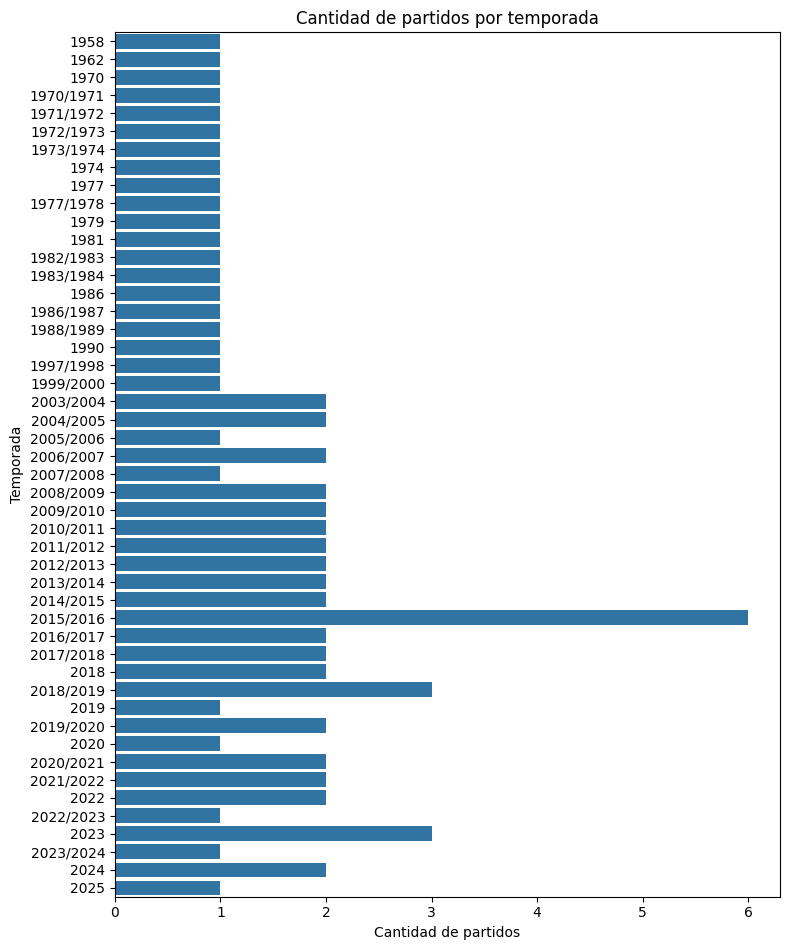

In [18]:
#Prueba grafica (x,y) donde se visualicen cant de partidos por año
plt.figure(figsize=(8, len(partidos_x_temp) * 0.2))  # Ajusta el alto según la cantidad de temporadas
sns.barplot(x='cantidad_partidos', y='season_name', data=partidos_x_temp)
plt.xlabel('Cantidad de partidos')
plt.ylabel('Temporada')
plt.title('Cantidad de partidos por temporada')
plt.tight_layout()  # Ajusta automáticamente los elementos para que no se superpongan
plt.show()

In [19]:
#como la temp 2015/16 es la de mas partidos me interesa ver sus variables para saber que datos tengo para trabajar
#comp_2015_2016=competitions[competitions['season_name']=='2015/2016']
#print(comp_2015_2016.columns)